In [1]:
# =========================
# LOAD DATA (PPG CHECK)
# =========================

from pathlib import Path
import pandas as pd

FILE_PATH = Path("../data/processed/eda_ppg_features_test2/features_all_test2.csv")

print("Current working dir:", Path.cwd())
print("Trying to load:", FILE_PATH)

if not FILE_PATH.exists():
    print("\n❌ File not found!")
else:
    print("\n✅ File found")

    try:
        df = pd.read_csv(FILE_PATH)
    except:
        df = pd.read_csv(FILE_PATH, sep=";")

    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

# -------------------------
# PPG FEATURES
# -------------------------
ppg_features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "RR_mean",
    "RR_std",
    "RR_min",
    "RR_max"
]

print("\nDescribe BEFORE cleaning:")

for f in ppg_features:
    if f in df.columns:
        print(f"\n{f}:")
        print(df[f].describe())

Current working dir: c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\notebooks
Trying to load: ..\data\processed\eda_ppg_features_test2\features_all_test2.csv

✅ File found

Shape: (5780, 16)

Columns:
['HR', 'HRV_RMSSD', 'RR_diff_std', 'HRV_SDNN', 'RR_mean', 'RR_std', 'RR_min', 'RR_max', 'RR_count', 'RR_quality', 'RR_valid', 'participant', 'time_sec', 'SC_PH', 'SC_RR', 'EDA_slope']

Describe BEFORE cleaning:

HR:
count    5780.000000
mean       80.025798
std        11.424437
min        54.150973
25%        72.290269
50%        78.520949
75%        86.429098
max       141.942360
Name: HR, dtype: float64

HRV_RMSSD:
count    5780.000000
mean       47.553638
std        16.090708
min         8.767506
25%        35.036242
50%        47.392854
75%        59.980737
max        94.688192
Name: HRV_RMSSD, dtype: float64

HRV_SDNN:
count    5780.000000
mean       62.416303
std        24.193318
min        15.359078
25%        45.011288
50%        58.716643
75%        76.520495
max      

In [2]:
def evaluate_ppg_features(df, features, participant_col="participant"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    report = {}

    print("\n==============================")
    print("PPG FEATURE EVALUATION REPORT")
    print("==============================")

    # =========================
    # 1. DISTRIBUTIONS
    # =========================
    print("\n=== DISTRIBUTIONS ===")
    for f in features:
        if f not in df.columns:
            continue

        skew = df[f].skew()
        kurt = df[f].kurtosis()

        print(f"\nFeature: {f}")
        print(f"Skewness: {skew:.3f}")
        print(f"Kurtosis: {kurt:.3f}")

        report[f] = {
            "skew": float(skew),
            "kurtosis": float(kurt)
        }

        plt.figure()
        df[f].hist(bins=50)
        plt.title(f"{f} (Skew={skew:.2f})")
        plt.show()

    # =========================
    # 2. OUTLIERS
    # =========================
    print("\n=== OUTLIERS (IQR) ===")
    for f in features:
        if f not in df.columns:
            continue

        Q1 = df[f].quantile(0.25)
        Q3 = df[f].quantile(0.75)
        IQR = Q3 - Q1

        outliers = df[(df[f] < Q1 - 1.5*IQR) | (df[f] > Q3 + 1.5*IQR)]
        ratio = len(outliers) / len(df)

        print(f"{f} outlier ratio: {ratio:.3f}")
        report[f]["outlier_ratio"] = float(ratio)

    # =========================
    # 3. CORRELATION
    # =========================
    print("\n=== CORRELATIONS ===")
    valid_features = [f for f in features if f in df.columns]
    corr = df[valid_features].corr()
    print(corr)

    plt.figure()
    plt.imshow(corr, interpolation='nearest')
    plt.colorbar()
    plt.xticks(range(len(valid_features)), valid_features, rotation=45)
    plt.yticks(range(len(valid_features)), valid_features)
    plt.title("PPG Correlation Matrix")
    plt.show()

    report["correlation_matrix"] = corr.to_dict()

    # =========================
    # 4. BETWEEN SUBJECT
    # =========================
    print("\n=== BETWEEN-PARTICIPANT VARIATION ===")
    group_means = df.groupby(participant_col)[valid_features].mean()

    for f in valid_features:
        std_between = group_means[f].std()
        std_total = df[f].std()

        ratio = std_between / std_total if std_total > 0 else 0

        print(f"{f}: between/total std = {ratio:.3f}")
        report[f]["between_subject_ratio"] = float(ratio)

    # =========================
    # 5. QUALITY SCORE
    # =========================
    print("\n=== FEATURE QUALITY SCORE ===")

    for f in valid_features:
        score = 0

        if report[f]["outlier_ratio"] < 0.05:
            score += 1

        if abs(report[f]["skew"]) < 2:
            score += 1

        if report[f]["between_subject_ratio"] > 0.3:
            score += 1

        print(f"{f} score: {score}/3")
        report[f]["quality_score"] = score

    return report

In [3]:
import numpy as np

# -------------------------
# HR (fysiologiskt rimligt)
# -------------------------
df = df[(df["HR"] > 40) & (df["HR"] < 200)]

# -------------------------
# RR INTERVAL (ms)
# -------------------------
df = df[(df["RR_mean"] > 300) & (df["RR_mean"] < 2000)]

# -------------------------
# HRV (ta bort extrema)
# -------------------------
for col in ["HRV_RMSSD", "HRV_SDNN", "RR_std"]:
    if col in df.columns:
        low, high = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(low, high)

# -------------------------
# RR min/max sanity
# -------------------------
if "RR_min" in df.columns and "RR_max" in df.columns:
    df = df[df["RR_min"] > 200]
    df = df[df["RR_max"] < 2500]

print("\nDescribe AFTER cleaning:")

for f in ppg_features:
    if f in df.columns:
        print(f"\n{f}:")
        print(df[f].describe())


Describe AFTER cleaning:

HR:
count    5780.000000
mean       80.025798
std        11.424437
min        54.150973
25%        72.290269
50%        78.520949
75%        86.429098
max       141.942360
Name: HR, dtype: float64

HRV_RMSSD:
count    5780.000000
mean       47.525034
std        15.957726
min        14.192889
25%        35.036242
50%        47.392854
75%        59.980737
max        81.847224
Name: HRV_RMSSD, dtype: float64

HRV_SDNN:
count    5780.000000
mean       62.307185
std        23.714100
min        21.547947
25%        45.011288
50%        58.716643
75%        76.520495
max       131.860314
Name: HRV_SDNN, dtype: float64

RR_mean:
count    5780.000000
mean      768.121482
std       102.474180
min       449.492188
25%       699.926813
50%       766.730769
75%       830.684932
max      1093.750000
Name: RR_mean, dtype: float64

RR_std:
count    5780.000000
mean       61.896590
std        23.541218
min        21.421859
25%        44.713765
50%        58.308783
75%        


PPG FEATURE EVALUATION REPORT

=== DISTRIBUTIONS ===

Feature: HR
Skewness: 0.644
Kurtosis: 0.633


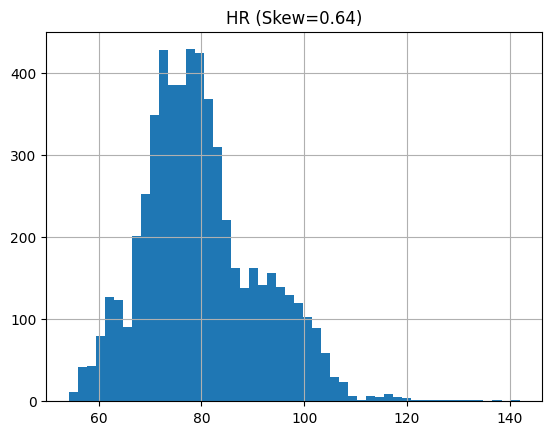


Feature: HRV_RMSSD
Skewness: 0.009
Kurtosis: -0.801


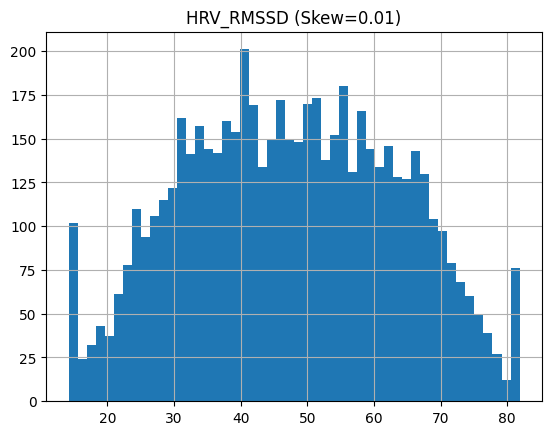


Feature: HRV_SDNN
Skewness: 0.696
Kurtosis: 0.184


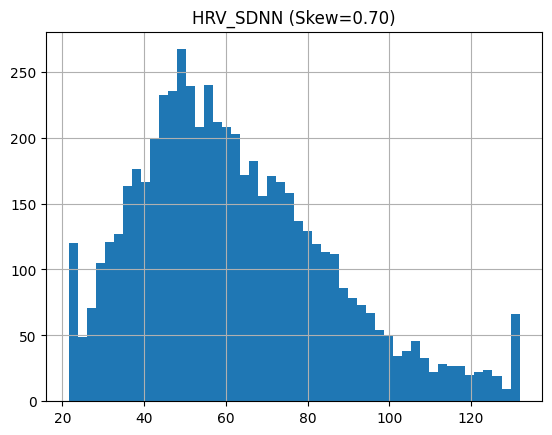


Feature: RR_mean
Skewness: 0.230
Kurtosis: -0.036


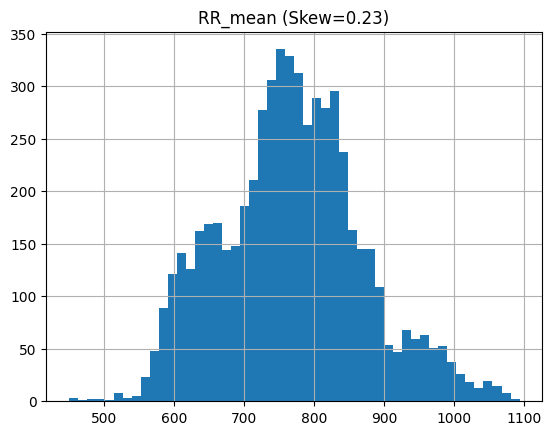


Feature: RR_std
Skewness: 0.696
Kurtosis: 0.182


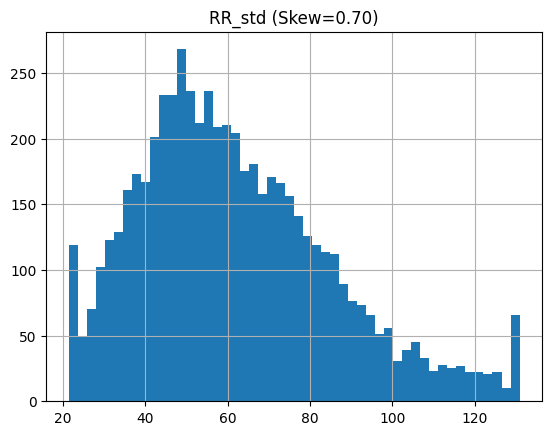


Feature: RR_min
Skewness: 0.073
Kurtosis: -0.316


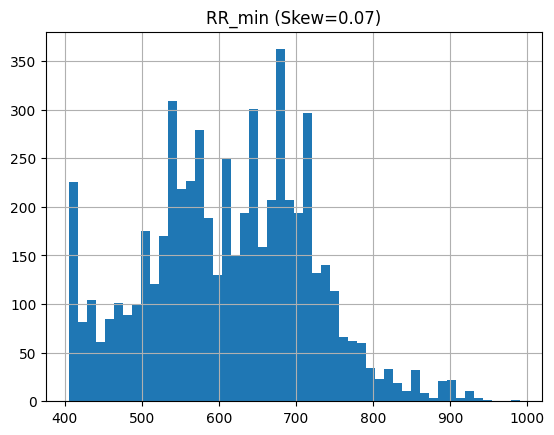


Feature: RR_max
Skewness: -0.219
Kurtosis: -0.334


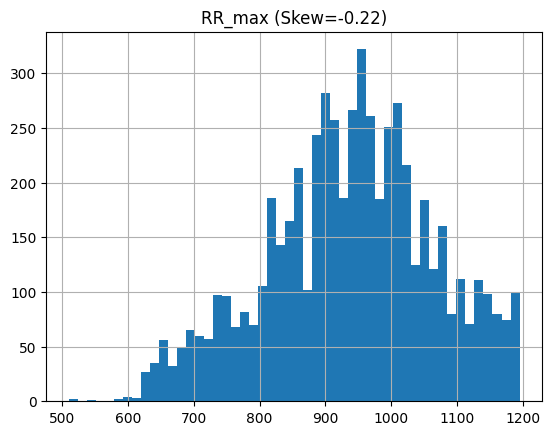


=== OUTLIERS (IQR) ===
HR outlier ratio: 0.011
HRV_RMSSD outlier ratio: 0.000
HRV_SDNN outlier ratio: 0.020
RR_mean outlier ratio: 0.012
RR_std outlier ratio: 0.020
RR_min outlier ratio: 0.003
RR_max outlier ratio: 0.001

=== CORRELATIONS ===
                 HR  HRV_RMSSD  HRV_SDNN   RR_mean    RR_std    RR_min  \
HR         1.000000  -0.398765 -0.207498 -0.961031 -0.205813 -0.742783   
HRV_RMSSD -0.398765   1.000000  0.736895  0.456246  0.736432  0.004784   
HRV_SDNN  -0.207498   0.736895  1.000000  0.271842  0.999997 -0.317029   
RR_mean   -0.961031   0.456246  0.271842  1.000000  0.269955  0.742268   
RR_std    -0.205813   0.736432  0.999997  0.269955  1.000000 -0.318713   
RR_min    -0.742783   0.004784 -0.317029  0.742268 -0.318713  1.000000   
RR_max    -0.701937   0.699340  0.728867  0.758033  0.727837  0.264078   

             RR_max  
HR        -0.701937  
HRV_RMSSD  0.699340  
HRV_SDNN   0.728867  
RR_mean    0.758033  
RR_std     0.727837  
RR_min     0.264078  
RR_max   

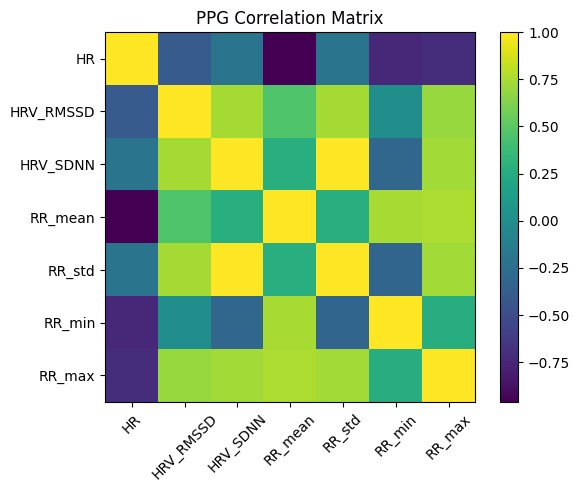


=== BETWEEN-PARTICIPANT VARIATION ===
HR: between/total std = 0.931
HRV_RMSSD: between/total std = 0.906
HRV_SDNN: between/total std = 0.795
RR_mean: between/total std = 0.941
RR_std: between/total std = 0.795
RR_min: between/total std = 0.861
RR_max: between/total std = 0.859

=== FEATURE QUALITY SCORE ===
HR score: 3/3
HRV_RMSSD score: 3/3
HRV_SDNN score: 3/3
RR_mean score: 3/3
RR_std score: 3/3
RR_min score: 3/3
RR_max score: 3/3


In [4]:
ppg_features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "RR_mean",
    "RR_std",
    "RR_min",
    "RR_max"
]

report_ppg = evaluate_ppg_features(df, ppg_features)